In [59]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from datetime import datetime



In [39]:
# Load the dataset
file_path = 'HR Analytics Assignment.csv'
df = pd.read_csv(file_path)

In [40]:
# Define a mapping for categorical ratings to numeric values
rating_map = {
    "Very Dissatisfied": 1,
    "Dissatisfied": 2,
    "Neutral": 3,
    "Satisfied": 4,
    "Very Satisfied": 5
}
# Apply the mapping to relevant columns
rating_columns = ['Overall Rating', 'Career Growth', 'Compensation and Benefits', 'Work-life Balance']
for col in rating_columns:
    df[col] = df[col].map(rating_map)


In [41]:
df.describe()

,Overall Rating,Career Growth,Compensation and Benefits,Work-life Balance
count,25866.000000,25866.000000,25866.000000,25866.00000
mean,3.707840,3.641576,3.049331,3.67784
std,1.256557,1.325245,1.333548,1.28195
min,1.000000,1.000000,1.000000,1.00000
25%,3.000000,3.000000,2.000000,3.00000
50%,4.000000,4.000000,3.000000,4.00000
75%,5.000000,5.000000,4.000000,5.00000
max,5.000000,5.000000,5.000000,5.00000


In [42]:
df.isnull().sum()

EmpID                         0
Location                     35
Gender                       35
Level                        35
Date Of Joining               0
Overall Rating                0
Career Growth                 0
Compensation and Benefits     0
Work-life Balance             0
Comments                     59
dtype: int64

In [43]:
df.set_index("EmpID",inplace=True)

In [44]:
df['Date Of Joining'] = pd.to_datetime(df['Date Of Joining'])

C:\Users\Ann S Vettoor\AppData\Local\Temp\ipykernel_7880\2679818189.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Of Joining'] = pd.to_datetime(df['Date Of Joining'])


In [45]:
df.head()

,Location,Gender,Level,Date Of Joining,Overall Rating,Career Growth,Compensation and Benefits,Work-life Balance,Comments
EmpID,,,,,,,,,
a80b49x693,LocD,Men,Middle,2019-05-10,4,4,3,4,It's a full package of privileged engagement.
a81b94x601,Remote,Men,Middle,2006-06-05,1,3,1,5,Everything is good
a81b10x636,LocC,Women,Middle,2022-06-02,5,5,5,5,Notice period
a80b73x624,LocA,Women,Junior,2022-05-10,4,4,3,3,"Attrition, people join and left very frequently."
a82b26x611,LocD,Women,Junior,2006-02-18,1,3,4,3,I worked in GE.\n All managers are totally unf...


In [46]:
df_missing_percent = df.isnull().sum()/len(df)
df_missing_percent

Location                     0.001353
Gender                       0.001353
Level                        0.001353
Date Of Joining              0.000000
Overall Rating               0.000000
Career Growth                0.000000
Compensation and Benefits    0.000000
Work-life Balance            0.000000
Comments                     0.002281
dtype: float64

Text(0, 0.5, 'Overall Rating')

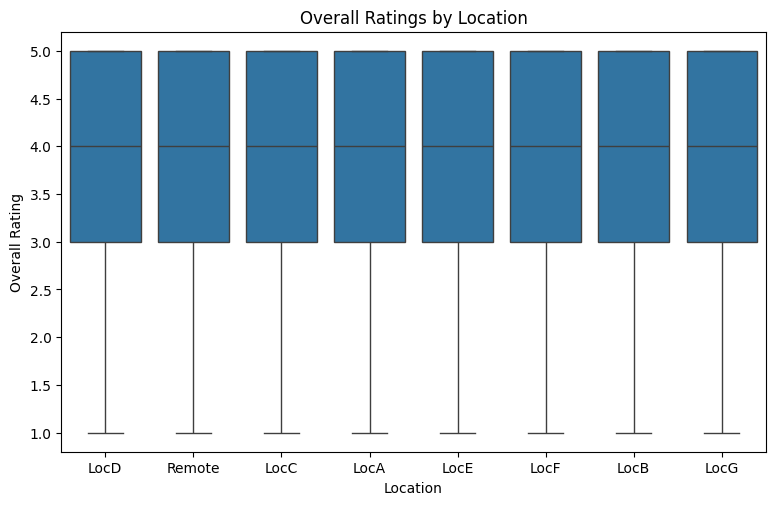

In [47]:
# 1. Overall rating w.r.t location
plt.figure(figsize=(20, 12))
plt.subplot(2, 2, 1)
sns.boxplot(data=df, x='Location', y='Overall Rating')
plt.title('Overall Ratings by Location')
plt.xlabel('Location')
plt.ylabel('Overall Rating')

Text(0, 0.5, 'Career Growth')

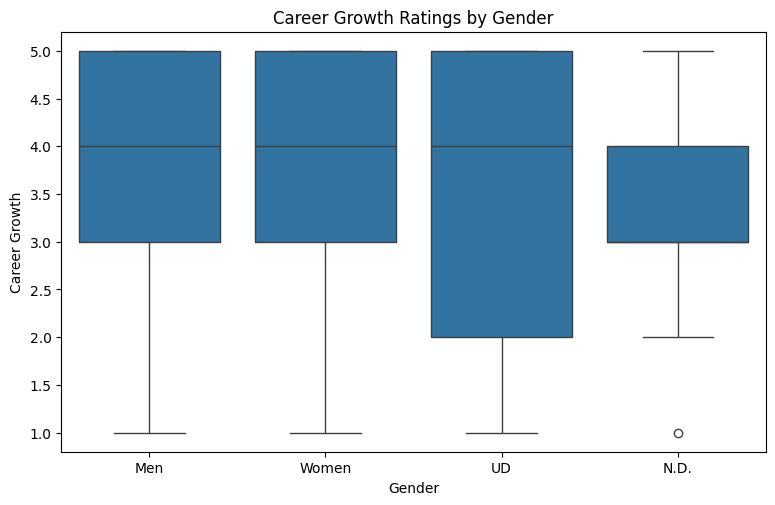

In [48]:
# 2. Career growth ratings w.r.t gender
plt.figure(figsize=(20, 12))
plt.subplot(2, 2, 2)
sns.boxplot(data=df, x='Gender', y='Career Growth')
plt.title('Career Growth Ratings by Gender')
plt.xlabel('Gender')
plt.ylabel('Career Growth')

C:\Users\Ann S Vettoor\AppData\Local\Temp\ipykernel_7880\432609323.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Level', y='Work-life Balance', ci=None, estimator=sum)


Text(0, 0.5, 'Sum of Work-Life Balance Ratings')

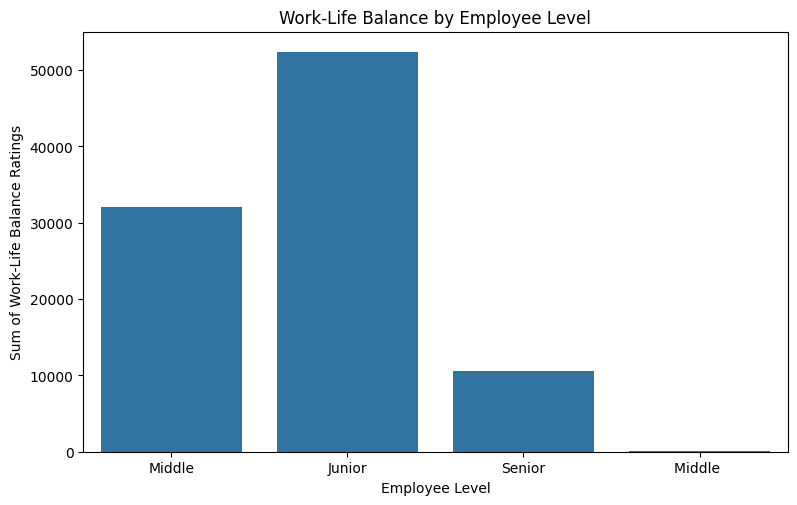

In [51]:

# 3. Work-life balance w.r.t employee level
plt.figure(figsize=(20, 12))
plt.subplot(2, 2, 3)
sns.barplot(data=df, x='Level', y='Work-life Balance', ci=None, estimator=sum)
plt.title('Work-Life Balance by Employee Level')
plt.xlabel('Employee Level')
plt.ylabel('Sum of Work-Life Balance Ratings')      ##################CHECK HERE WHY 2 TIMES MIDDLE IS COMING################33

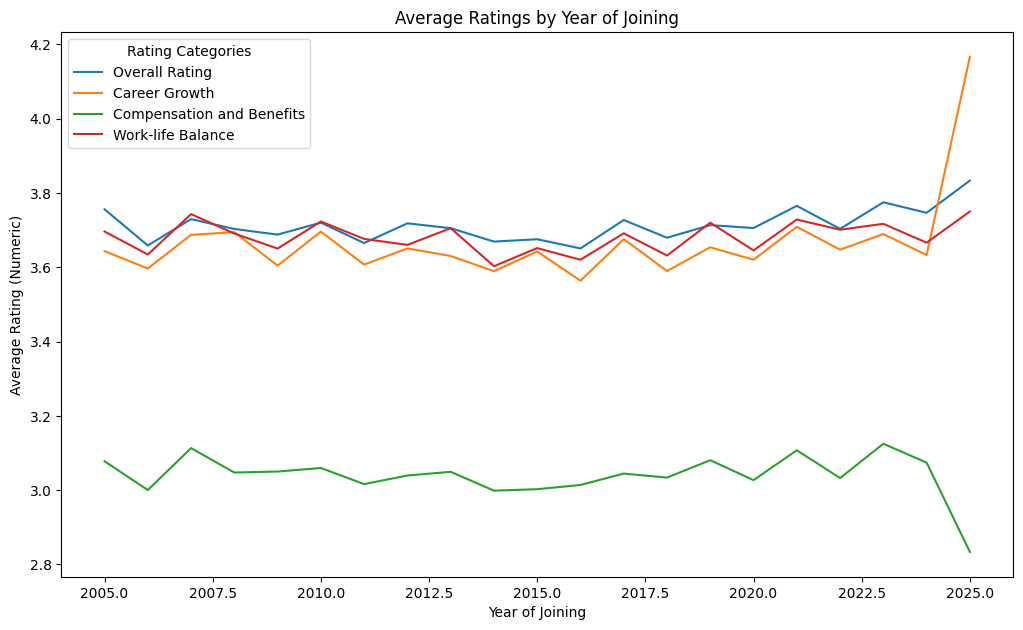

In [52]:
# 4. Average ratings by year of joining
plt.figure(figsize=(20, 12))
df['Year Of Joining'] = df['Date Of Joining'].dt.year
yearly_ratings = df.groupby('Year Of Joining')[rating_columns].mean().reset_index()

plt.subplot(2, 2, 4)
for col in rating_columns:
    plt.plot(yearly_ratings['Year Of Joining'], yearly_ratings[col], label=col)

plt.title('Average Ratings by Year of Joining')
plt.xlabel('Year of Joining')
plt.ylabel('Average Rating (Numeric)')
plt.legend(title='Rating Categories')

plt.tight_layout()
plt.show()


In [53]:

# Pivot Tables for Additional Insights
# Pivot table for overall ratings by location and gender
pivot_table = df.pivot_table(values='Overall Rating', index='Location', columns='Gender', aggfunc='mean')
print("Pivot Table: Overall Ratings by Location and Gender")
print(pivot_table)
pivot_table.to_csv('pivot_table_overall_ratings.csv')

Pivot Table: Overall Ratings by Location and Gender
Gender         Men      N.D.        UD     Women
Location                                        
LocA      3.542422  5.000000  3.484848  3.800863
LocB      3.653037  3.333333  3.593750  3.778887
LocC      3.638404       NaN  3.564103  3.800958
LocD      3.605988  3.666667  3.618557  3.835655
LocE      3.636728  5.000000  3.330097  3.765615
LocF      3.642983  4.250000  3.698113  3.815041
LocG      3.660296       NaN  3.484536  3.840195
Remote    3.693642       NaN  3.572650  3.810773


In [57]:
correlation_matrix = df[['Overall Rating', 'Career Growth', 'Compensation and Benefits', 'Work-life Balance']].corr()
correlation_matrix

,Overall Rating,Career Growth,Compensation and Benefits,Work-life Balance
Overall Rating,1.000000,0.701910,0.625932,0.672094
Career Growth,0.701910,1.000000,0.695075,0.761828
Compensation and Benefits,0.625932,0.695075,1.000000,0.654157
Work-life Balance,0.672094,0.761828,0.654157,1.000000


In [60]:
highest_correlation = correlation_matrix['Overall Rating'][1:].idxmax()
highest_value = correlation_matrix['Overall Rating'][1:].max()

# Display results
print("Correlation Matrix:")
print(correlation_matrix)
print(f"\nThe factor with the highest correlation with Overall Rating is: {highest_correlation} with a value of {highest_value:.2f}")

# Save a summarized dataset for LLM input
summary_data = {
    'Factor': ['Career Growth', 'Compensation and Benefits', 'Work-life Balance'],
    'Correlation with Overall Rating': correlation_matrix['Overall Rating'][1:].values
}
summary_df = pd.DataFrame(summary_data)
summary_file_path = 'correlation_summary.csv'
summary_df.to_csv(summary_file_path, index=False)

Correlation Matrix:
                           Overall Rating  Career Growth  \
Overall Rating                   1.000000       0.701910   
Career Growth                    0.701910       1.000000   
Compensation and Benefits        0.625932       0.695075   
Work-life Balance                0.672094       0.761828   

                           Compensation and Benefits  Work-life Balance  
Overall Rating                              0.625932           0.672094  
Career Growth                               0.695075           0.761828  
Compensation and Benefits                   1.000000           0.654157  
Work-life Balance                           0.654157           1.000000  

The factor with the highest correlation with Overall Rating is: Career Growth with a value of 0.70


In [62]:
# Define tenure groups
df['Tenure (Years)'] = (datetime.now() - df['Date Of Joining']).dt.days / 365.25

# Categorize associates into high-tenured and Covid-era joiners
df['Tenure Category'] = df['Tenure (Years)'].apply(
    lambda x: 'High Tenured (15+ Years)' if x >= 15 else ('Covid-Era Joiner (2020+)' if x <= 3 else 'Others')
)

# Count dissatisfaction levels in each group
dissatisfaction_levels = ['Very Dissatisfied', 'Dissatisfied']

def is_dissatisfied(overall_rating):
    return overall_rating in dissatisfaction_levels

df['Dissatisfied'] = df['Overall Rating'].apply(is_dissatisfied)

# Group by tenure category and calculate dissatisfaction rate
dissatisfaction_summary = df.groupby('Tenure Category').agg(
    # Total_Associates=('EmpID', 'count'),
    Dissatisfied_Associates=('Dissatisfied', 'sum'),
    Dissatisfaction_Rate=('Dissatisfied', 'mean')
).reset_index()

dissatisfaction_summary['Dissatisfaction_Rate'] = dissatisfaction_summary['Dissatisfaction_Rate'] * 100

# Save the results to a CSV file
output_file = 'Dissatisfaction_By_Tenure.csv'
dissatisfaction_summary.to_csv(output_file, index=False)


In [63]:
dissatisfaction_summary

,Tenure Category,Dissatisfied_Associates,Dissatisfaction_Rate
0,Covid-Era Joiner (2020+),0,0.0
1,High Tenured (15+ Years),0,0.0
2,Others,0,0.0
